In [ ]:
import pandas as pd
import sqlite3

db_path = "SQLite-db/sessions.db"
conn = sqlite3.connect(db_path)

## Build the pool of synthetic viewer eligible for digital activation. 

Table List: PK / FK
viewer_weights: viewer (viewer_weight) / target_group (model_version)
digital_sessions: session_id / target_group
target_group_mappings: target_group -  182 unique target groups

digital_sessions, unique target_group entries
target_group - FK to target_group_mappings$id
(m3049,mover50, fover50, m1229, f3049, f1229)
target_group -> id : many -> one (filtered to ids in digital_sessions)
str pattern: - m/f + age
target_group is never null

Do I use viewer_weights at all in this operation?

## Activation / Deactivation

What is "activation"? What does it mean to be "eligible"? Take a viewer_id from viewer_weights and assign a pairing match to a session in digital_sessions??

In [1]:
# Column lookup
import sqlite3
conn = sqlite3.connect('SQLite-db/sessions.db')
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(digital_sessions)")
cols = cursor.fetchall()
[print(f'{col[1]} ({col[2]})') for col in cols]

tv_day (DATE)
channel_id (TEXT)
session_start (TIMESTAMP)
session_finish (TIMESTAMP)
session_duration (INTEGER)
session_id (INTEGER)
session_type (INTEGER)
content_start (TIMESTAMP)
content_end (TIMESTAMP)
content_offset (INTEGER)
device_type (TEXT)
device_id (TEXT)
target_group (TEXT)
program_title (TEXT)
player_id (TEXT)
is_timeshifted (INTEGER)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [68]:
viewer_sessions_df = pd.read_sql("""
SELECT * 
FROM viewer_sessions 
LIMIT 10
""", conn)
viewer_sessions_df

,tv_day,channel_id,viewer_id,session_start,session_finish,session_duration,model_version,device_id,session_id,delivery_id,resolution_id,session_source,timeshifted_start,target_groups
0,2025-09-12,0,21038_7,2025-09-12 19:02:38,2025-09-12 19:24:19,1302,4.30.2_spin+at.20250829113426,c7072258-2ec8-48ef-8722-582ec8a8ef35,177d3a1d-5153-47c9-bd3a-1d515397c9a8,2,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""
1,2025-09-12,0,28170_15,2025-09-12 17:31:55,2025-09-12 17:31:58,4,4.30.2_spin+at.20250829113426,c7a84610-ce18-4cef-a846-10ce182cef44,5d129e10-9fa8-42d7-929e-109fa872d761,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00p6$'`\x02\x00\x000..."
2,2025-09-12,0,21735_21,2025-09-12 13:07:18,2025-09-12 14:54:37,6440,4.30.2_spin+at.20250829113426,c80fe630-2f99-4cb3-8fe6-302f996cb3ba,9706dcb8-ea84-4890-86dc-b8ea84d8904d,1,2,tracked,None,"b""p6$'`\x02\x00\x00\xf0 $'`\x02\x00\x00\xf0\xf..."
3,2025-09-12,0,29452_5,2025-09-12 14:07:27,2025-09-12 14:09:44,138,4.30.2_spin+at.20250829113426,c978af24-69ee-495b-b8af-2469eea95bd5,6b8ed148-9d8f-4eb4-8ed1-489d8f1eb412,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""
4,2025-09-12,0,16390_26,2025-09-12 18:15:15,2025-09-12 18:15:24,10,4.30.2_spin+at.20250829113426,cbd23888-71d9-433b-9238-8871d9133b45,6cda6098-846f-4422-9a60-98846f44226e,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xf0,$'`\x02\x00\x00"""
5,2025-09-12,0,24145_23,2025-09-12 13:01:59,2025-09-12 13:38:01,2163,4.30.2_spin+at.20250829113426,cd892666-ce18-4d1e-8926-66ce18dd1e67,1e2542e2-ba41-4c94-a542-e2ba417c94cd,1,2,tracked,None,"b""p\xf2t'`\x02\x00\x000:$'`\x02\x00\x000\xf2t'..."
6,2025-09-12,0,27991_25,2025-09-12 15:23:47,2025-09-12 15:24:52,66,4.30.2_spin+at.20250829113426,ceeb3632-7fce-46a0-ab36-327fce36a037,8609101f-179c-40b6-8910-1f179c60b609,1,2,tracked,None,"b""\xf0\xc5t'`\x02\x00\x00\xf0\xf1\x8d%`\x02\x0..."
7,2025-09-12,0,28827_29,2025-09-12 08:52:06,2025-09-12 08:52:47,42,4.30.2_spin+at.20250829113426,d057ccda-f613-4768-97cc-daf6131768b5,adf0562c-99ea-465c-b056-2c99ea565c91,1,2,tracked,None,"b""\xf0\xc4t'`\x02\x00\x00p6$'`\x02\x00\x00p\x0..."
8,2025-09-12,0,19341_8,2025-09-12 18:40:21,2025-09-12 19:23:37,2597,4.30.2_spin+at.20250829113426,d1945819-610e-468f-9458-19610e368f28,4e1aaa69-43bd-4851-9aaa-6943bdd851f3,2,2,tracked,None,"b""p6$'`\x02\x00\x000\xf2t'`\x02\x00\x00p\xf2t'..."
9,2025-09-12,0,18745_30,2025-09-12 19:28:28,2025-09-12 19:28:34,7,4.30.2_spin+at.20250829113426,d290085f-d837-4606-9008-5fd837a606a0,91b79e8b-b491-4e7f-b79e-8bb4911e7fe1,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xf0\x82q'`\x02\x0..."


In [ ]:
activations_df = pd.read_sql("""
SELECT 
vs.session_id, vs.channel_id, vs.tv_day, vs.session_start, vs.session_finish, 
vs.viewer_id, vw.viewer_weight, tgm.target_group, tgm.id as digital_bucket
FROM viewer_sessions vs 
JOIN viewer_weights vw
ON vs.viewer_id = vw.viewer
and vw.model_version = vs.model_version
JOIN digital_target_group_mappings tgm 
ON vw.target_group = tgm.target_group
WHERE vs.tv_day = '2025-09-12'
""", conn)
print(activations_df.shape)
activations_df.head()

# Next step:  Prefer synthetic viewer that have not yet been activated on the current broadcast day. 
# Sort eligible viewer by ascending representational weight within each demographic bucket. 
# Assign each synthetic viewer to the same six demographic buckets used for digital sessions. 

# """representational weight within each demographic bucket""" # What is this??

# SQL logic: rank() OVER (partition by session_id, order by "not yet activated on current broadcast day" weight asc)
# "not yet activated on current broadcast day" = IF(COUNT(1) > 0 WHERE viewer_sessions$tv_day = digital_sessions$tv_day, 0, 1)
# 

(1508182, 9)


,session_id,channel_id,tv_day,session_start,session_finish,viewer_id,viewer_weight,target_group,id
0,177d3a1d-5153-47c9-bd3a-1d515397c9a8,0,2025-09-12,2025-09-12 19:02:38,2025-09-12 19:24:19,21038_7,145.812286,2-70_99-h1,fover50
1,5d129e10-9fa8-42d7-929e-109fa872d761,0,2025-09-12,2025-09-12 17:31:55,2025-09-12 17:31:58,28170_15,106.529757,2-50_59-h0,fover50
2,9706dcb8-ea84-4890-86dc-b8ea84d8904d,0,2025-09-12,2025-09-12 13:07:18,2025-09-12 14:54:37,21735_21,42.714085,2-50_59-h0,fover50
3,6b8ed148-9d8f-4eb4-8ed1-489d8f1eb412,0,2025-09-12,2025-09-12 14:07:27,2025-09-12 14:09:44,29452_5,111.186355,2-70_99-h1,fover50
4,6cda6098-846f-4422-9a60-98846f44226e,0,2025-09-12,2025-09-12 18:15:15,2025-09-12 18:15:24,16390_26,20.797248,1-60_69-h1,mover50


In [129]:
activations_df.groupby(["viewer_id"]).agg({"session_id": "count"}).sort_values(by="session_id", ascending=False).head(20)

,session_id
viewer_id,
23277_28,4500
27781_28,893
27781_20,878
19077_5,652
16390_16,530
25404_9,479
7455_2,442
7455_19,384
18555_24,369


In [132]:
viewer = activations_df[activations_df["viewer_id"] == '16390_16'].sort_values(by=["viewer_id", "session_start"])

In [138]:
activations_df[activations_df["session_id"] == '3da99a20-c3a5-4a82-a99a-20c3a54a8270'].sort_values(by="viewer_id")

,session_id,channel_id,tv_day,session_start,session_finish,viewer_id,viewer_weight,target_group,id
385089,3da99a20-c3a5-4a82-a99a-20c3a54a8270,3101,2025-09-12,2025-09-12 04:22:38,2025-09-12 04:32:51,16390_13,47.390449,1-60_69-h1,mover50
688087,3da99a20-c3a5-4a82-a99a-20c3a54a8270,3110,2025-09-12,2025-09-12 04:22:38,2025-09-12 04:32:51,16390_13,47.390449,1-60_69-h1,mover50
297003,3da99a20-c3a5-4a82-a99a-20c3a54a8270,3101,2025-09-12,2025-09-12 04:22:38,2025-09-12 04:32:51,16390_16,41.253557,1-60_69-h1,mover50
675299,3da99a20-c3a5-4a82-a99a-20c3a54a8270,3110,2025-09-12,2025-09-12 04:22:38,2025-09-12 04:32:51,16390_16,41.253557,1-60_69-h1,mover50


In [ ]:
viewer.sort_values(by="session_start")
# I'm still getting dupe rows....
# Multiple channels on the same session....

,session_id,channel_id,tv_day,session_start,session_finish,viewer_id,viewer_weight,target_group,id,corrected_channel_id
297003,3da99a20-c3a5-4a82-a99a-20c3a54a8270,3101,2025-09-12,2025-09-12 04:22:38,2025-09-12 04:32:51,16390_16,41.253557,1-60_69-h1,mover50,3101
675299,3da99a20-c3a5-4a82-a99a-20c3a54a8270,3110,2025-09-12,2025-09-12 04:22:38,2025-09-12 04:32:51,16390_16,41.253557,1-60_69-h1,mover50,3110
566359,222d1fbb-55f5-45bc-ad1f-bb55f535bcd9,3102,2025-09-12,2025-09-12 04:32:52,2025-09-12 04:32:53,16390_16,41.253557,1-60_69-h1,mover50,3102
1176832,ff4249d0-03b1-4c12-8249-d003b11c125a,3400,2025-09-12,2025-09-12 04:32:59,2025-09-12 04:33:05,16390_16,41.253557,1-60_69-h1,mover50,3400
1302784,ff4249d0-03b1-4c12-8249-d003b11c125a,3404,2025-09-12,2025-09-12 04:32:59,2025-09-12 04:33:05,16390_16,41.253557,1-60_69-h1,mover50,3404
...,...,...,...,...,...,...,...,...,...,...
1323086,0734c3bd-79dd-4f06-b4c3-bd79ddcf06a6,3500,2025-09-12,2025-09-12 21:25:35,2025-09-12 22:11:39,16390_16,41.253557,1-60_69-h1,mover50,3500
1096808,35079fa0-0148-4c4f-879f-a001485c4f5f,3303,2025-09-12,2025-09-12 22:11:52,2025-09-12 22:12:21,16390_16,41.253557,1-60_69-h1,mover50,3303
491413,47aeed79-a028-4f45-aeed-79a0289f4576,3101,2025-09-12,2025-09-12 22:12:23,2025-09-12 22:12:28,16390_16,41.253557,1-60_69-h1,mover50,3101
682186,47aeed79-a028-4f45-aeed-79a0289f4576,3110,2025-09-12,2025-09-12 22:12:23,2025-09-12 22:12:28,16390_16,41.253557,1-60_69-h1,mover50,3110


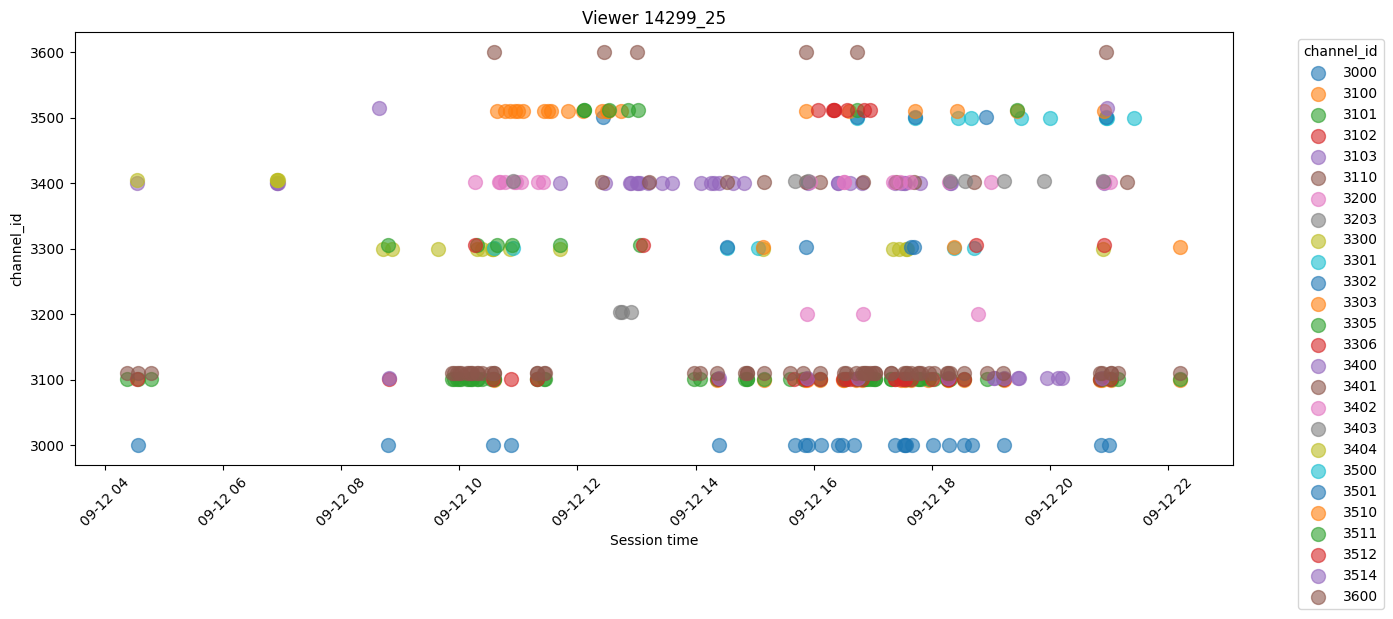

In [134]:
import matplotlib.pyplot as plt
viewer["corrected_channel_id"] = viewer["channel_id"].where(
    viewer["channel_id"] != 0, 3000
)
plot_df = (
    viewer
    .drop_duplicates(subset=["session_id", "corrected_channel_id"])
    .sort_values("session_start")
    .copy()
)

plot_df["session_start"] = pd.to_datetime(plot_df["session_start"])

plt.figure(figsize=(14, 6))

for channel_id, g in plot_df.groupby("corrected_channel_id"):
    plt.scatter(
        g["session_start"],
        [channel_id] * len(g),
        s=100,
        alpha=0.6,
        label=str(channel_id)
    )

plt.xlabel("Session time")
plt.ylabel("channel_id")
plt.title("Viewer 14299_25")
plt.legend(title="channel_id", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [135]:
# Sort eligible viewer by ascending representational weight within each demographic bucket. 
bucket_weight_df = pd.read_sql("""
SELECT
--vw.viewer, vw.target_group, vw.viewer_weight, tgm.id
*
FROM viewer_weights vw
LEFT JOIN digital_target_group_mappings tgm 
ON vw.target_group = tgm.target_group
WHERE model_version = '4.30.2_spin+at.20250829113426'
AND id = 'fover50'
""", conn)
bucket_weight_df

,model_version,viewer,target_group,viewer_weight,id,display_name,target_group
0,4.30.2_spin+at.20250829113426,23124_14,2-50_59-h0,111.716194,fover50,"Female, 50+",2-50_59-h0
1,4.30.2_spin+at.20250829113426,23124_23,2-50_59-h0,66.357739,fover50,"Female, 50+",2-50_59-h0
2,4.30.2_spin+at.20250829113426,23695_23,2-50_59-h0,49.636499,fover50,"Female, 50+",2-50_59-h0
3,4.30.2_spin+at.20250829113426,23695_30,2-50_59-h0,23.247474,fover50,"Female, 50+",2-50_59-h0
4,4.30.2_spin+at.20250829113426,25297_18,2-50_59-h0,10.860759,fover50,"Female, 50+",2-50_59-h0
...,...,...,...,...,...,...,...
21892,4.30.2_spin+at.20250829113426,804_26,2-70_99-h1,81.189963,fover50,"Female, 50+",2-70_99-h1
21893,4.30.2_spin+at.20250829113426,8404_11,2-70_99-h1,133.166136,fover50,"Female, 50+",2-70_99-h1
21894,4.30.2_spin+at.20250829113426,8404_3,2-70_99-h1,175.497093,fover50,"Female, 50+",2-70_99-h1
21895,4.30.2_spin+at.20250829113426,8772_17,2-70_99-h1,87.315998,fover50,"Female, 50+",2-70_99-h1


In [125]:
df = pd.read_sql("""
SELECT * FROM target_group_mappings 
""", conn)
df

,id,display_name,target_group
0,all,"Everyone, 3+",2-50_59-h1
1,all,"Everyone, 3+",2-60_69
2,all,"Everyone, 3+",1-20_29-h1
3,all,"Everyone, 3+",2-14_19-h0
4,all,"Everyone, 3+",2-70_99
...,...,...,...
1222,e1849,"Everyone, 18-49",1-18_49
1223,f1839,"Female, 18-39",2-18_39
1224,f1849,"Female, 18-49",2-18_49
1225,m1839,"Male, 18-39",1-18_39


In [126]:
df.drop_duplicates().shape

(1164, 3)

In [84]:
df = pd.read_sql("""
SELECT * FROM viewer_sessions 
WHERE model_version = '4.30.2_spin+at.20250829113426'
AND session_id = '177d3a1d-5153-47c9-bd3a-1d515397c9a8'
""", conn)
df.head(20)

,tv_day,channel_id,viewer_id,session_start,session_finish,session_duration,model_version,device_id,session_id,delivery_id,resolution_id,session_source,timeshifted_start,target_groups
0,2025-09-12,0,21038_7,2025-09-12 19:02:38,2025-09-12 19:24:19,1302,4.30.2_spin+at.20250829113426,c7072258-2ec8-48ef-8722-582ec8a8ef35,177d3a1d-5153-47c9-bd3a-1d515397c9a8,2,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""


In [87]:
df = pd.read_sql("""
SELECT * FROM target_group_mappings 
WHERE target_group in ('ac_mfover55', '2-70_99-h1')
""", conn)
df.head(20)

,id,display_name,target_group
0,ac_mfover55,"Everyone, 55+",ac_mfover55
1,all,"Everyone, 3+",2-70_99-h1
2,fover12,"Female, 12+",2-70_99-h1
3,fover3,"Female, 3+",2-70_99-h1
4,fover30,"Female, 30+",2-70_99-h1
5,fover30plus,"Female, 30+, householdlead: yes",2-70_99-h1
6,fover50,"Female, 50+",2-70_99-h1
7,fover50plus,"Female, 50+, householdlead: yes",2-70_99-h1
8,fover60,"Female, 60+",2-70_99-h1
9,mfover12,"Everyone, 12+",2-70_99-h1


In [83]:
activations_df.drop_duplicates().shape

(6, 8)

In [82]:
activations_df[["session_id","viewer_id", "viewer_weight", "target_group", "target_groups"]].drop_duplicates()

,session_id,viewer_id,viewer_weight,target_group,target_groups
0,177d3a1d-5153-47c9-bd3a-1d515397c9a8,21038_7,145.812286,2-70_99-h1,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""
18,177d3a1d-5153-47c9-bd3a-1d515397c9a8,21038_7,145.812286,ac_mfover55,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""
19,177d3a1d-5153-47c9-bd3a-1d515397c9a8,29258_9,204.841642,1-70_99-h0,"b""p*n'`\x02\x00\x00\xf0\xf1\x8d%`\x02\x00\x00"""
34,177d3a1d-5153-47c9-bd3a-1d515397c9a8,29258_9,204.841642,ac_mfover55,"b""p*n'`\x02\x00\x00\xf0\xf1\x8d%`\x02\x00\x00"""
35,177d3a1d-5153-47c9-bd3a-1d515397c9a8,29257_9,230.877563,2-70_99-h1,"b""\xb0\xcd\x92'`\x02\x00\x00\xb0\xcb\x92'`\x02..."
53,177d3a1d-5153-47c9-bd3a-1d515397c9a8,29257_9,230.877563,ac_mfover55,"b""\xb0\xcd\x92'`\x02\x00\x00\xb0\xcb\x92'`\x02..."


In [67]:
viewer_weights_df = pd.read_sql("""
SELECT * FROM viewer_weights 
WHERE model_version = '4.30.2_spin+at.20250829113426'
AND target_group in ('1-30_39-h0', '1-30_39-h1', '1-40_49-h0', '1-40_49-h1')
""", conn)
viewer_weights_df.head(20)

,model_version,viewer,target_group,viewer_weight
0,4.30.2_spin+at.20250829113426,1395_27,1-30_39-h0,17.506838
1,4.30.2_spin+at.20250829113426,16674_10,1-30_39-h0,40.705042
2,4.30.2_spin+at.20250829113426,17317_6,1-30_39-h0,76.959684
3,4.30.2_spin+at.20250829113426,20333_13,1-30_39-h0,354.628481
4,4.30.2_spin+at.20250829113426,20333_25,1-30_39-h0,170.936030
5,4.30.2_spin+at.20250829113426,20925_19,1-30_39-h0,75.980768
6,4.30.2_spin+at.20250829113426,21001_10,1-30_39-h0,57.603831
7,4.30.2_spin+at.20250829113426,21692_26,1-30_39-h0,140.499733
8,4.30.2_spin+at.20250829113426,23171_14,1-30_39-h0,126.760453
9,4.30.2_spin+at.20250829113426,23374_20,1-30_39-h0,125.168380


In [37]:
digital_sessions_df = pd.read_sql("""
SELECT * 
FROM digital_sessions 
LIMIT 1000
""", conn)
digital_sessions_df.head()

,tv_day,channel_id,session_start,session_finish,session_duration,session_id,session_type,content_start,content_end,content_offset,device_type,device_id,target_group,program_title,player_id,is_timeshifted
0,2025-09-01,3100,2025-09-01 15:36:31,2025-09-01 15:36:39,8,2478884526235042948,1,2025-09-01 15:36:09,2025-09-01 15:36:17,22,Desktop,a17567393381255F51DCC8CDF86D98408C4764210FB60B...,m3049,SOKO KITZBUEHEL,orfon.web.agtt,0
1,2025-09-01,3100,2025-09-01 15:53:38,2025-09-01 15:55:28,110,-9170201654474515450,1,2025-09-01 01:58:08,2025-09-01 01:59:58,50130,Desktop,a1756741979342BA07C7815E2734E5CE36B16B62A23A9E...,m3049,FORMEL 1 GP NIEDERLANDE HL,orfon.web.agtt,0
2,2025-09-01,3100,2025-09-01 16:08:05,2025-09-01 16:44:25,2180,-7579215933857723276,1,2025-09-01 16:03:53,2025-09-01 16:40:13,252,Mobile,a17567423156411F62622FC4D20AD7D9E1B9AF05A1631B...,mover50,SMART10 DAS QUIZ MIT DEN ZEHN MOEGLICHKEITEN,orfon.web.agtt,0
3,2025-09-01,3100,2025-09-01 17:25:57,2025-09-01 17:30:01,244,9068904426905465091,1,2025-09-01 11:07:24,2025-09-01 11:11:28,22713,Mobile,a1756746202110E8BFE3A8DEF243373EE7894FF75D2C64...,mover50,SOKO DONAU,orfon.web.agtt,0
4,2025-09-01,3100,2025-09-01 18:55:57,2025-09-01 19:02:03,366,-1658072054937992787,1,2025-09-01 18:55:34,2025-09-01 19:01:40,23,Desktop,a17567468029528F1324F4EFCB4A591CAD094CB984C5EE...,m3049,CHAMPIONS,orfon.web.agtt,0


In [23]:
viewer_sessions_df = pd.read_sql("""
SELECT * 
FROM viewer_sessions 
LIMIT 10
""", conn)
viewer_sessions_df.head()

,tv_day,channel_id,viewer_id,session_start,session_finish,session_duration,model_version,device_id,session_id,delivery_id,resolution_id,session_source,timeshifted_start,target_groups
0,2025-09-12,0,21038_7,2025-09-12 19:02:38,2025-09-12 19:24:19,1302,4.30.2_spin+at.20250829113426,c7072258-2ec8-48ef-8722-582ec8a8ef35,177d3a1d-5153-47c9-bd3a-1d515397c9a8,2,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""
1,2025-09-12,0,28170_15,2025-09-12 17:31:55,2025-09-12 17:31:58,4,4.30.2_spin+at.20250829113426,c7a84610-ce18-4cef-a846-10ce182cef44,5d129e10-9fa8-42d7-929e-109fa872d761,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00p6$'`\x02\x00\x000..."
2,2025-09-12,0,21735_21,2025-09-12 13:07:18,2025-09-12 14:54:37,6440,4.30.2_spin+at.20250829113426,c80fe630-2f99-4cb3-8fe6-302f996cb3ba,9706dcb8-ea84-4890-86dc-b8ea84d8904d,1,2,tracked,None,"b""p6$'`\x02\x00\x00\xf0 $'`\x02\x00\x00\xf0\xf..."
3,2025-09-12,0,29452_5,2025-09-12 14:07:27,2025-09-12 14:09:44,138,4.30.2_spin+at.20250829113426,c978af24-69ee-495b-b8af-2469eea95bd5,6b8ed148-9d8f-4eb4-8ed1-489d8f1eb412,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xb03$'`\x02\x00\x00"""
4,2025-09-12,0,16390_26,2025-09-12 18:15:15,2025-09-12 18:15:24,10,4.30.2_spin+at.20250829113426,cbd23888-71d9-433b-9238-8871d9133b45,6cda6098-846f-4422-9a60-98846f44226e,1,2,tracked,None,"b""\xf0\xf1\x8d%`\x02\x00\x00\xf0,$'`\x02\x00\x00"""


In [43]:
digital_sessions_df = pd.read_sql("""
SELECT distinct is_timeshifted
FROM digital_sessions
""", conn)
digital_sessions_df.head()

,is_timeshifted
0,0
1,1


In [53]:
target_group_mappings_df = pd.read_sql("""
SELECT * FROM target_group_mappings 
where 
--id = 'm1229'
target_group = '1-70_99-h0'
""", conn)
target_group_mappings_df


,id,display_name,target_group
0,all,"Everyone, 3+",1-70_99-h0
1,mfover12,"Everyone, 12+",1-70_99-h0
2,mfover18,"Everyone, 18+",1-70_99-h0
3,mfover3,"Everyone, 3+",1-70_99-h0
4,mfover30,"Everyone, 30+",1-70_99-h0
5,mfover40,"Everyone, 40+",1-70_99-h0
6,mfover50,"Everyone, 50+",1-70_99-h0
7,mfover60,"Everyone, 60+",1-70_99-h0
8,mover12,"Male, 12+",1-70_99-h0
9,mover18,"Male, 18+",1-70_99-h0


In [54]:
target_group_mappings_df = pd.read_sql("""
SELECT * FROM target_group_mappings 
where 
id = 'mover50'
--target_group = '1-70_99-h0'
""", conn)
target_group_mappings_df


,id,display_name,target_group
0,mover50,"Male, 50+",1-60_69
1,mover50,"Male, 50+",1-70_99
2,mover50,"Male, 50+",1-50_59-h0
3,mover50,"Male, 50+",1-50_59-h1
4,mover50,"Male, 50+",1-50_59-h1
5,mover50,"Male, 50+",1-70_99-h1
6,mover50,"Male, 50+",1-60_69-h0
7,mover50,"Male, 50+",1-70_99-h0
8,mover50,"Male, 50+",1-50_59-h0
9,mover50,"Male, 50+",1-60_69-h1


In [55]:
target_group_mappings_df = pd.read_sql("""
SELECT * FROM target_group_mappings 
where 
id = 'mover50'
and target_group = '1-70_99-h0'
""", conn)
target_group_mappings_df


,id,display_name,target_group
0,mover50,"Male, 50+",1-70_99-h0
